In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("../dataset/processed/feature_data.csv")
print("Full Dataset :",df.shape)

Full Dataset : (180516, 33)


In [4]:
# Keep only late shipments  we're predicting severity, not whether it's late
reg_df = df.copy()
print(f"Dataset size: {reg_df.shape}")
print(f"\ndelay_gap distribution:")
print(reg_df['delay_gap'].describe())
print(f"\nEarly deliveries: {(reg_df['delay_gap'] < 0).sum()}")
print(f"On time:          {(reg_df['delay_gap'] == 0).sum()}")
print(f"Late deliveries:  {(reg_df['delay_gap'] > 0).sum()}")

Dataset size: (180516, 33)

delay_gap distribution:
count    180516.000000
mean          0.565811
std           1.490977
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delay_gap, dtype: float64

Early deliveries: 43366
On time:          33751
Late deliveries:  103399


## Regression Task — Predicting Delay Gap on All Shipments

Reframed from filtering late shipments only to predicting delay_gap
across all orders. delay_gap = Days for shipping (real) - Days for 
shipment (scheduled).  

Negative = arrived early. Zero = on time. Positive = late.  

This is more useful business-wise: given any new order, estimate
how many days off schedule it will be, before it ships.

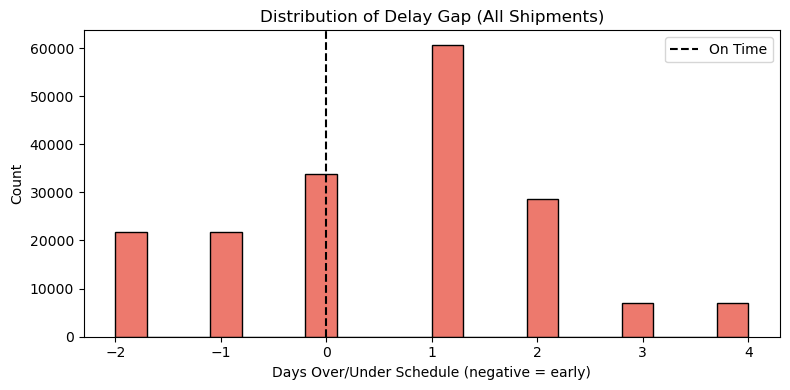

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(reg_df['delay_gap'], bins=20, color='#e74c3c')
plt.axvline(0, color='black', linestyle='--', label='On Time')
plt.title('Distribution of Delay Gap (All Shipments)')
plt.xlabel('Days Over/Under Schedule (negative = early)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/regression_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Target Variable Distribution

Shows the spread of actual shipping days among late deliveries.
The model needs to predict this value for any new shipment flagged
as high risk by the classifier.

In [18]:
target = 'delay_gap'

cols_to_drop = [
    'Late_delivery_risk',              # binary version of target
    'Days for shipping (real)',        # directly computes target
    'Days for shipment (scheduled)',   # directly computes target
    'Order_processing_days',           # overlaps with above
    'customer_avg_delay_gap',          # historical version of target
    'Shipping Mode_encoded',          # duplicate of Shipping_mode_risk
               # encodes scheduled windows, dominates model
]
reg_df = df[df['delay_gap'] > 0].copy()
reg_df = reg_df.drop(columns=[c for c in cols_to_drop if c in reg_df.columns])

X = reg_df.drop(columns=[target])
y = reg_df[target]

print(f"Features: {X.shape[1]}")
print(f"Target range: {y.min()} to {y.max()}")
print(f"Target mean: {y.mean():.2f}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

Features: 26
Target range: 1 to 4
Target mean: 1.62

Feature columns:
['Benefit per order', 'Sales per customer', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'Product Status', 'is_holiday_window', 'is_weekend_order', 'Shipping_mode_risk', 'customer_total_orders', 'customer_late_rate', 'Price Tier', 'Market_encoded', 'Order Region_encoded', 'Customer Segment_encoded', 'Department Name_encoded', 'Type_encoded', 'Order Status_encoded']


## Feature Setup

Shipping_mode_risk dropped as a feature here  it encodes the scheduled
delivery window and would dominate the model, preventing it from learning
from other meaningful signals like customer history, geography, and order
characteristics.

The model learns delay patterns from: customer behaviour, market, product
type, order value, and timing signals.

In [23]:
# Chronological split — same logic as classification
split_index = int(len(reg_df) * 0.8)
train_df = reg_df.iloc[:split_index]
test_df = reg_df.iloc[split_index:]

X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (82719, 26)
X_test:  (20680, 26)


## Chronological Split

Chronological 80/20 split consistent with classification notebook.
Train on past orders, test on future orders  reflects real deployment
where the model predicts delay for new incoming shipments.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("=== Linear Regression (Baseline) ===")
print(f"RMSE: {lr_rmse:.4f} days")
print(f"MAE:  {lr_mae:.4f} days")
print(f"R²:   {lr_r2:.4f}")

=== Linear Regression (Baseline) ===
RMSE: 0.8760 days
MAE:  0.7099 days
R²:   0.0008


## Baseline: Linear Regression

Linear regression as our performance floor.
StandardScaler applied since linear regression is sensitive to feature scale.

Metrics:
- RMSE (Root Mean Squared Error): average error in days, penalises large errors more
- MAE (Mean Absolute Error): average absolute error in days
- R² (R-squared): how much variance the model explains. 1.0 = perfect, 0 = useless

In [21]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("=== Random Forest Regressor ===")
print(f"RMSE: {rf_rmse:.4f} days")
print(f"MAE:  {rf_mae:.4f} days")
print(f"R²:   {rf_r2:.4f}")

=== Random Forest Regressor ===
RMSE: 0.6679 days
MAE:  0.4764 days
R²:   0.4192


## Main Model: Random Forest Regressor

Random Forest chosen for regression because:
- Handles non-linear relationships well
- Robust to outliers in shipping day values
- No scaling needed tree based model
- n_jobs=-1 uses all CPU cores for faster training

n_estimators=200 balances accuracy and training time.  
max_depth=10 prevents overfitting on the late shipments subset.

In [22]:
results=pd.DataFrame({
    "Model":['Linear Regression','Random Forest'],
    "RMSE":[lr_rmse,rf_rmse],
    "MAE":[lr_mae,rf_mae],
    "R2":[lr_r2,rf_r2]
}).round(4)
print(results.to_string(index=False))

            Model   RMSE    MAE     R2
Linear Regression 0.8760 0.7099 0.0008
    Random Forest 0.6679 0.4764 0.4192


## Model Comparison

Random Forest should outperform Linear Regression on both RMSE and R².  
Lower RMSE and MAE = better. Higher R² = better.

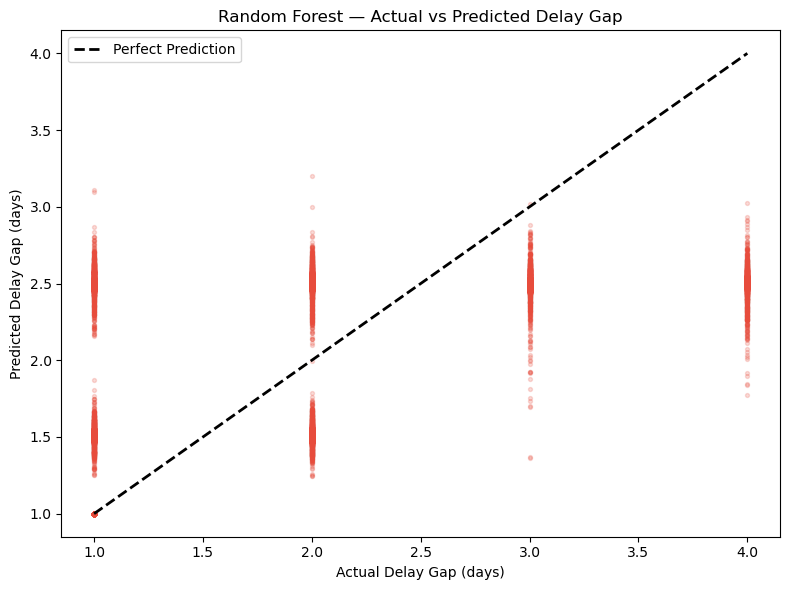

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_preds, alpha=0.2, color='#e74c3c', s=8)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Delay Gap (days)')
plt.ylabel('Predicted Delay Gap (days)')
plt.title('Random Forest — Actual vs Predicted Delay Gap')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/regression_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Actual vs Predicted

Points close to the dashed line = accurate predictions.  
The tighter the cluster around the diagonal, the better the model.  
Spread above the line = underestimates (predicts fewer days than actual).  
Spread below the line = overestimates (predicts more days than actual).

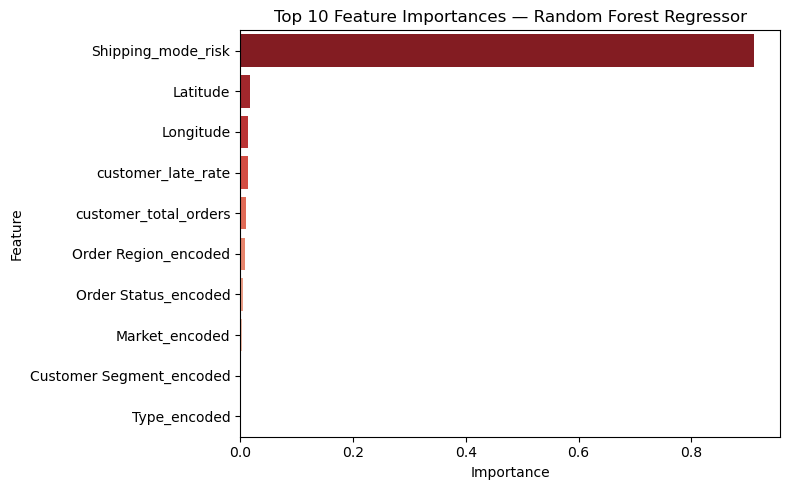

                 Feature  Importance
      Shipping_mode_risk    0.911459
                Latitude    0.017220
               Longitude    0.014689
      customer_late_rate    0.013975
   customer_total_orders    0.010933
    Order Region_encoded    0.007932
    Order Status_encoded    0.005266
          Market_encoded    0.003272
Customer Segment_encoded    0.002181
            Type_encoded    0.002032


In [26]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Reds_r')
plt.title('Top 10 Feature Importances — Random Forest Regressor')
plt.tight_layout()
plt.savefig('reports/figures/regression_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))

In [27]:
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(rf, 'models/rf_regressor.pkl')
print("Saved.")

Saved.
